--- RESUMEN ESTADÍSTICO GENERAL ---
              mean        std       min        max
perfil                                            
par       5.309884   8.921174  0.174538  29.635367
seq      13.765417  24.063421  0.331180  79.395111
weights   5.060193   8.524551  0.143467  28.327159

Speedup del Paralelo: 2.59x más rápido que Secuencial.
Speedup de Pesos/Heap: 2.72x más rápido que Secuencial.


/tmp/ipykernel_49611/1794848219.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='perfil', y='total_t', palette='Set2')


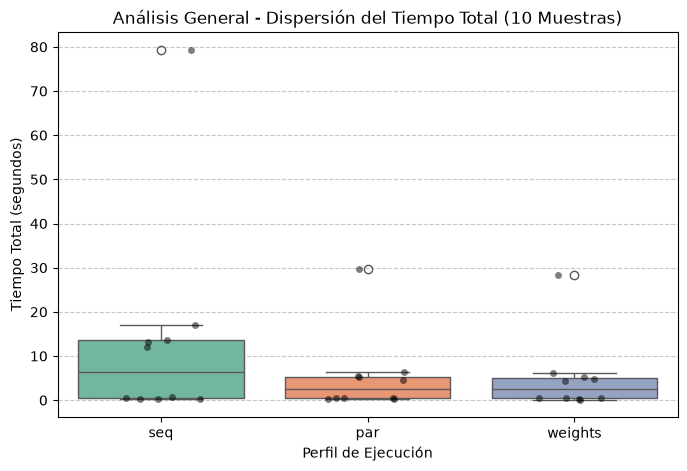

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("results/benchmark_granular_workflow.csv")

# 1. Agrupación estadística descriptiva rápida
print("--- RESUMEN ESTADÍSTICO GENERAL ---")
resumen = df.groupby('perfil')['total_t'].agg(['mean', 'std', 'min', 'max'])
print(resumen)

# 2. Calcular el Speedup Promedio
mean_seq = resumen.loc['seq', 'mean']
mean_par = resumen.loc['par', 'mean']
mean_weights = resumen.loc['weights', 'mean']

print(f"\nSpeedup del Paralelo: {mean_seq / mean_par:.2f}x más rápido que Secuencial.")
print(f"Speedup de Pesos/Heap: {mean_seq / mean_weights:.2f}x más rápido que Secuencial.")

# 3. Graficar la dispersión total de los tres métodos
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='perfil', y='total_t', palette='Set2')
sns.stripplot(data=df, x='perfil', y='total_t', color='black', alpha=0.5, jitter=0.2) # Muestra los puntos reales
plt.title("Análisis General - Dispersión del Tiempo Total (10 Muestras)")
plt.ylabel("Tiempo Total (segundos)")
plt.xlabel("Perfil de Ejecución")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

        REPORTE ESTADÍSTICO GENERAL DEL BENCHMARK

[1] Métricas de Rendimiento Temporal (Segundos):
             t_p1                          t_p2                           t_p3                          total_t                      
             mean       std       max      mean       std       max       mean        std        max       mean        std        max
perfil                                                                                                                               
par      0.159952  0.026202  0.211198  0.027580  0.002799  0.034201   5.122351   8.911497  29.434745   5.309884   8.921174  29.635367
seq      0.422385  0.076103  0.546474  0.000325  0.000038  0.000404  13.342708  24.044380  78.957051  13.765417  24.063421  79.395111
weights  0.156615  0.030464  0.208013  0.027596  0.002470  0.033515   4.875982   8.519956  28.146556   5.060193   8.524551  28.327159

🚀 Ganancia de Velocidad (Speedup Macro):
  • Método Paralelo: 2.59x más rápido que el Secuencia

/tmp/ipykernel_49611/109350359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='perfil', y='total_t', palette='Set2', width=0.5)



💾 Panel visual guardado en: 'results/general_analysis_dashboard.png'


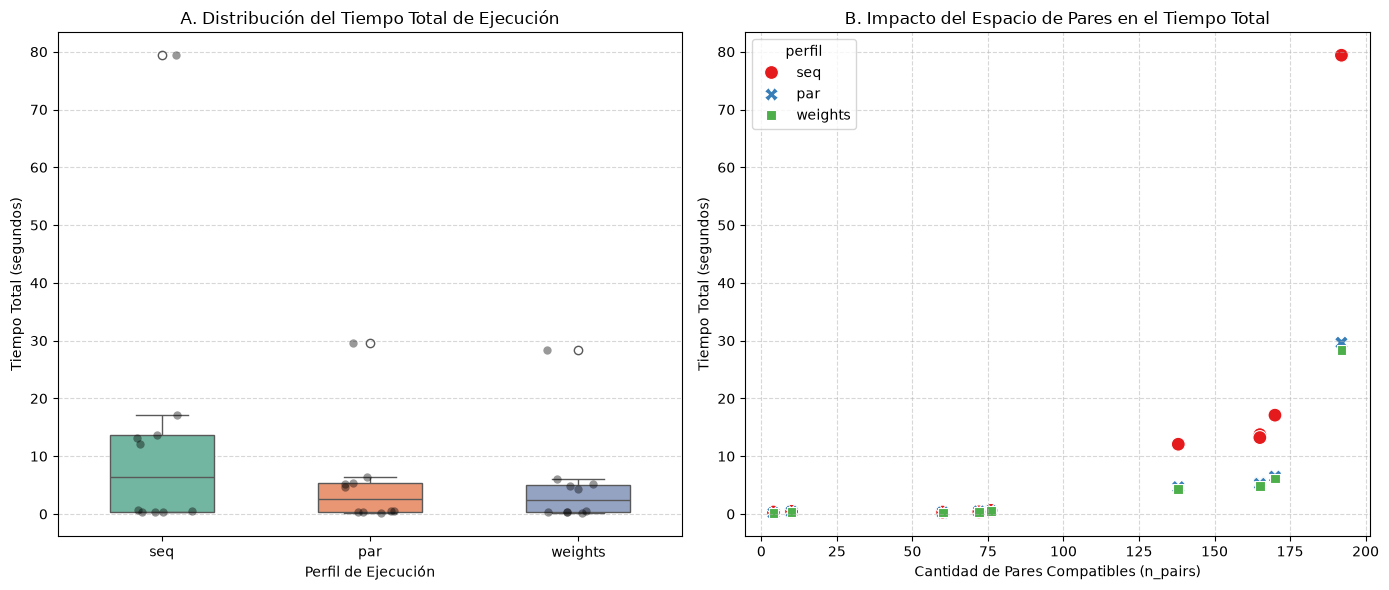

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cargar el archivo de datos generado por tu main_processor_all.py
csv_path = "results/benchmark_granular_workflow.csv"
df = pd.read_csv(csv_path)

print("=" * 60)
print("        REPORTE ESTADÍSTICO GENERAL DEL BENCHMARK")
print("=" * 60)

# --- SECCIÓN 1: COMPORTAMIENTO TEMPORAL POR PERFIL ---
print("\n[1] Métricas de Rendimiento Temporal (Segundos):")
columnas_tiempo = ['t_p1', 't_p2', 't_p3', 'total_t']
resumen_tiempos = df.groupby('perfil')[columnas_tiempo].agg(['mean', 'std', 'max']).round(6)
print(resumen_tiempos.to_string())

# Calcular Speedup Relativo basado en la media del tiempo total
mean_seq = df[df['perfil'] == 'seq']['total_t'].mean()
mean_par = df[df['perfil'] == 'par']['total_t'].mean()
mean_weights = df[df['perfil'] == 'weights']['total_t'].mean()

print("\n🚀 Ganancia de Velocidad (Speedup Macro):")
print(f"  • Método Paralelo: {mean_seq / mean_par:.2f}x más rápido que el Secuencial.")
print(f"  • Método de Pesos: {mean_seq / mean_weights:.2f}x más rápido que el Secuencial.")


# --- SECCIÓN 2: CARACTERIZACIÓN TOPOLÓGICA DE LAS MUESTRAS ---
print("\n" + "=" * 60)
print("[2] Caracterización de la Complejidad de las Redes (Conteos):")
columnas_conteo = ['n_attractors', 'n_pairs', 'n_fields']

# Como los tres perfiles evalúan las mismas redes, agrupamos por muestra para describir la población de redes
resumen_topologia = df[df['perfil'] == 'seq'][columnas_conteo].describe().loc[['mean', 'std', 'min', 'max']]
print(resumen_topologia.round(2).to_string())


# --- SECCIÓN 3: VALIDACIÓN DE PARIDAD DE RESULTADOS ---
# Verificamos si los tres métodos llegaron exactamente al mismo número de campos atractores por muestra
parity_check = df.groupby('sample')['n_fields'].nunique()
falla_paridad = parity_check[parity_check > 1].count()

print("\n" + "=" * 60)
print("[3] Verificación de Paridad Algorítmica:")
if falla_paridad == 0:
    print("  ✅ ¡ÉXITO! Los 3 métodos hallaron exactamente la misma cantidad de Campos Atractores en todas las muestras.")
else:
    print(f"  ❌ ALERTA: Hay {falla_paridad} muestras donde los métodos NO coinciden en los resultados.")
print("=" * 60)


# --- SECCIÓN 4: PANEL VISUAL (DASHBOARD) ---
# Configuramos un gráfico de dos subplots para tu documentación o paper
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot A: Dispersión del Tiempo Total por Perfil
sns.boxplot(ax=axes[0], data=df, x='perfil', y='total_t', palette='Set2', width=0.5)
sns.stripplot(ax=axes[0], data=df, x='perfil', y='total_t', color='black', alpha=0.4, jitter=0.15, size=6)
axes[0].set_title("A. Distribución del Tiempo Total de Ejecución")
axes[0].set_ylabel("Tiempo Total (segundos)")
axes[0].set_xlabel("Perfil de Ejecución")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Subplot B: Relación entre Complejidad (Pares Compatibles) y Tiempo Total
sns.scatterplot(ax=axes[1], data=df, x='n_pairs', y='total_t', hue='perfil', style='perfil', s=100, palette='Set1')
axes[1].set_title("B. Impacto del Espacio de Pares en el Tiempo Total")
axes[1].set_ylabel("Tiempo Total (segundos)")
axes[1].set_xlabel("Cantidad de Pares Compatibles (n_pairs)")
axes[1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("results/general_analysis_dashboard.png", dpi=300)
print("\n💾 Panel visual guardado en: 'results/general_analysis_dashboard.png'")
plt.show()